# Hotel Booking : Exploratory Data Analysis (EDA)

In [5]:
# Import additional necessary libraries for EDA and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

# Optional: Set display options for better DataFrame viewing
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.2f}'.format)

print('✅ Additional libraries loaded and display options set.')

✅ Additional libraries loaded and display options set.


In [ ]:
# ── Load raw data ─────────────────────────────────────────────────────────────
df = pd.read_csv("../data/processed/eda_final_dataset.csv")

## 1. Data Preparation for EDA

In [7]:
# Calculate 'total_nights' as it's a crucial aggregated feature
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
print('✅ `total_nights` calculated.')

✅ `total_nights` calculated.


## 2. Basic Information and Descriptive Statistics

In [8]:
# Display basic information about the DataFrame
print("DataFrame Info:")
df.info()

# Display the shape of the DataFrame
print("\nDataFrame Shape:", df.shape)

# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics for Numerical Columns:")
display(df.describe())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87219 entries, 0 to 87218
Data columns (total 49 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87219 non-null  object 
 1   is_canceled                     87219 non-null  int64  
 2   lead_time                       87219 non-null  float64
 3   arrival_date_year               87219 non-null  int64  
 4   arrival_date_month              87219 non-null  object 
 5   arrival_date_week_number        87219 non-null  int64  
 6   arrival_date_day_of_month       87219 non-null  int64  
 7   stays_in_weekend_nights         87219 non-null  int64  
 8   stays_in_week_nights            87219 non-null  int64  
 9   adults                          87219 non-null  int64  
 10  children                        87219 non-null  float64
 11  babies                          87219 non-null  int64  
 12  country         

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,average_daily_rate,required_car_parking_spaces,total_of_special_requests,total_nights,total_guests,total_revenue,has_children,is_weekend_stay,has_special_requests,is_direct_booking,is_peak_season,revenue_per_guest,average_night_value,clv_proxy
count,87219.00,87219.00,87219.00,87219.00,87219.00,87219.00,87219.00,87219.00,87219.00,87219.00,87219.00,87219.00,87219.00,87219.00,87219.00,87219.00,87219.00,87219.00,87219.00,87219.00,87219.00,87219.00,87219.00,87219.00,87219.00,87219.00,87219.00,87219.00,87219.00,87219.00
mean,0.28,79.38,2016.21,26.83,15.82,1.00,2.62,1.88,0.14,0.01,0.04,0.02,0.18,0.27,81.09,0.75,106.02,0.08,0.69,3.63,2.03,388.60,0.10,0.60,0.50,0.14,0.24,197.42,55.42,499.41
std,0.45,83.74,0.69,13.67,8.84,1.03,2.04,0.62,0.46,0.11,0.19,0.14,1.73,0.71,109.98,10.00,50.37,0.28,0.82,2.74,0.79,338.33,0.31,0.49,0.50,0.35,0.43,183.38,28.11,454.35
min,0.00,0.00,2015.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,11.00,2016.00,16.00,8.00,0.00,1.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,9.00,0.00,72.25,0.00,0.00,2.00,2.00,153.00,0.00,0.00,0.00,0.00,0.00,85.25,37.96,189.00
50%,0.00,49.00,2016.00,27.00,16.00,1.00,2.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,9.00,0.00,98.20,0.00,0.00,3.00,2.00,299.20,0.00,1.00,0.00,0.00,0.00,151.50,50.00,372.00
75%,1.00,125.00,2017.00,37.00,23.00,2.00,4.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,240.00,0.00,134.10,0.00,1.00,5.00,2.00,504.00,0.00,1.00,1.00,0.00,0.00,248.00,67.00,648.00
max,1.00,347.00,2017.00,53.00,31.00,19.00,50.00,55.00,10.00,10.00,1.00,1.00,72.00,18.00,535.00,391.00,252.00,8.00,3.00,69.00,55.00,1764.00,1.00,1.00,1.00,1.00,1.00,7590.00,252.00,2424.00


## 3. Target Variable Distribution: `is_canceled`

Cancellation Counts:
 is_canceled
Not Canceled    63210
Canceled        24009
Name: count, dtype: int64

Cancellation Percentage:
 is_canceled
Not Canceled   72.47
Canceled       27.53
Name: proportion, dtype: float64


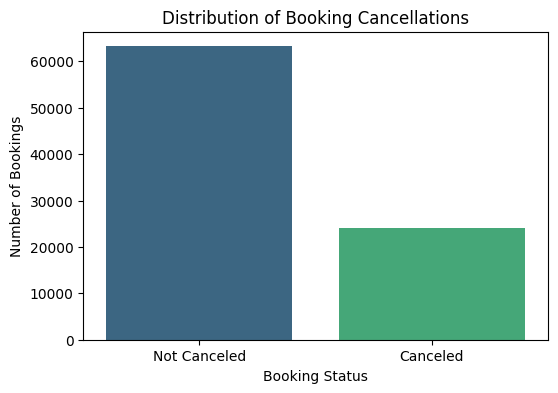

In [9]:
# Count and percentage of cancellations
cancellation_counts = df['is_canceled'].value_counts().rename(index={0: 'Not Canceled', 1: 'Canceled'})
cancellation_percentage = df['is_canceled'].value_counts(normalize=True).rename(index={0: 'Not Canceled', 1: 'Canceled'}) * 100

print("Cancellation Counts:\n", cancellation_counts)
print("\nCancellation Percentage:\n", cancellation_percentage)

# Plot the distribution
plt.figure(figsize=(6, 4))
sns.barplot(x=cancellation_counts.index, y=cancellation_counts.values, palette='viridis', hue=cancellation_counts.index, legend=False)
plt.title('Distribution of Booking Cancellations')
plt.xlabel('Booking Status')
plt.ylabel('Number of Bookings')
plt.show()

## 4. Distributions, Outliers, and Comparison of Numerical Features

### 4.1. Lead Time

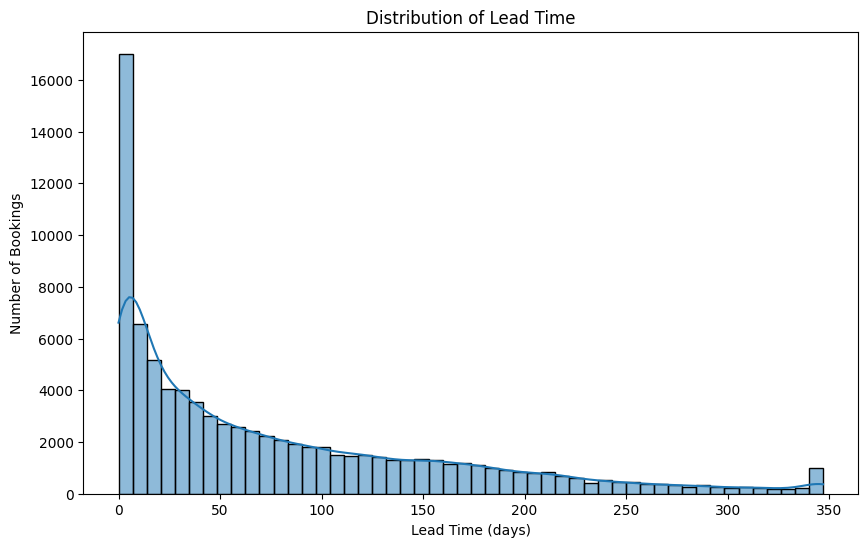

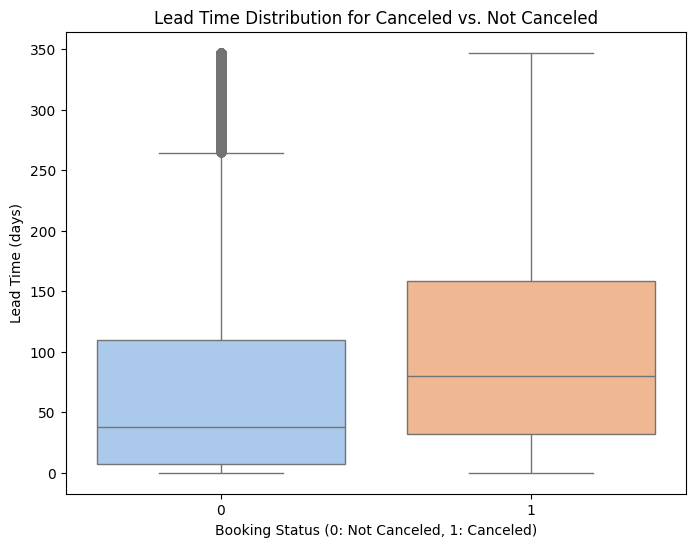

In [10]:
# Distribution of 'lead_time'
plt.figure(figsize=(10, 6))
sns.histplot(df['lead_time'], bins=50, kde=True)
plt.title('Distribution of Lead Time')
plt.xlabel('Lead Time (days)')
plt.ylabel('Number of Bookings')
plt.show()

# Box plot for 'lead_time' by 'is_canceled' to visualize outliers and trends
plt.figure(figsize=(8, 6))
sns.boxplot(x='is_canceled', y='lead_time', data=df, hue='is_canceled', palette='pastel', legend=False)
plt.title('Lead Time Distribution for Canceled vs. Not Canceled')
plt.xlabel('Booking Status (0: Not Canceled, 1: Canceled)')
plt.ylabel('Lead Time (days)')
plt.show()

### 4.2. Average Daily Rate (ADR)

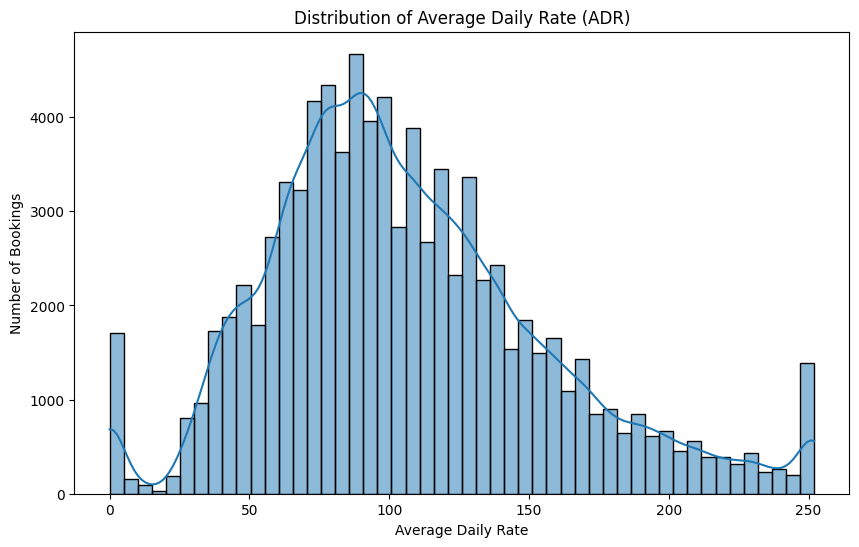

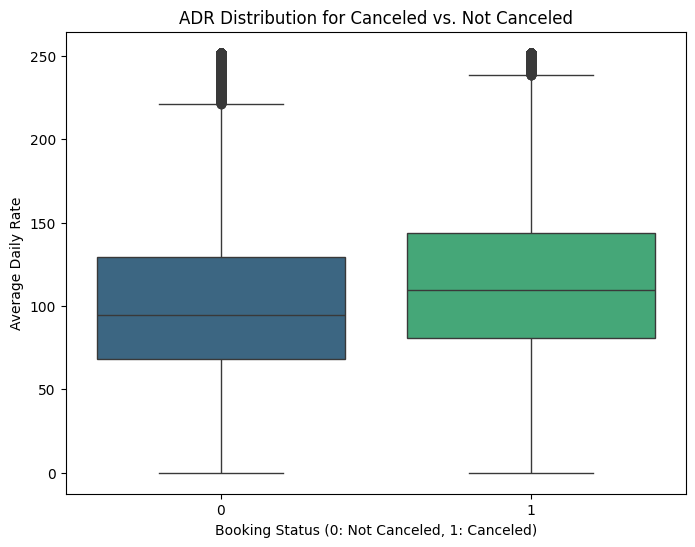

In [11]:
# Distribution of 'average_daily_rate'
plt.figure(figsize=(10, 6))
sns.histplot(df['average_daily_rate'], bins=50, kde=True)
plt.title('Distribution of Average Daily Rate (ADR)')
plt.xlabel('Average Daily Rate')
plt.ylabel('Number of Bookings')
plt.show()

# Box plot for 'average_daily_rate' by 'is_canceled'
plt.figure(figsize=(8, 6))
sns.boxplot(x='is_canceled', y='average_daily_rate', data=df, hue='is_canceled', palette='viridis', legend=False)
plt.title('ADR Distribution for Canceled vs. Not Canceled')
plt.xlabel('Booking Status (0: Not Canceled, 1: Canceled)')
plt.ylabel('Average Daily Rate')
plt.show()

### 4.3. Total Nights

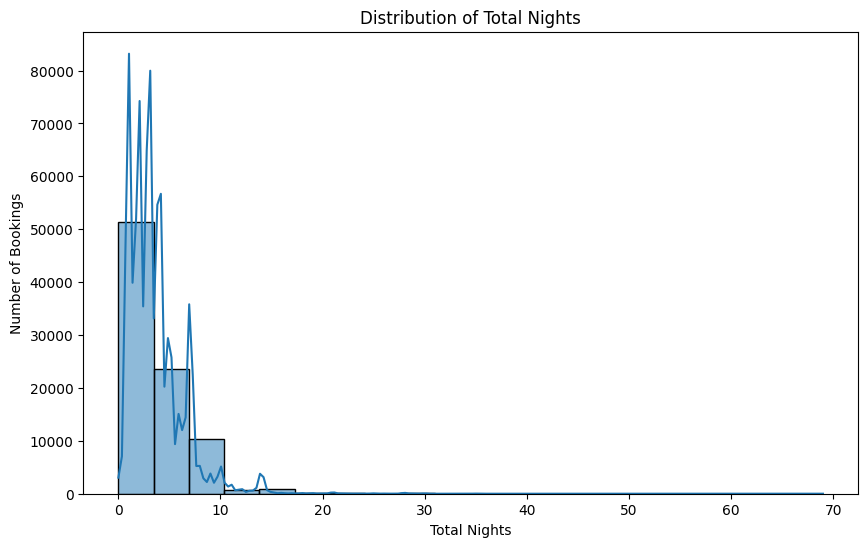

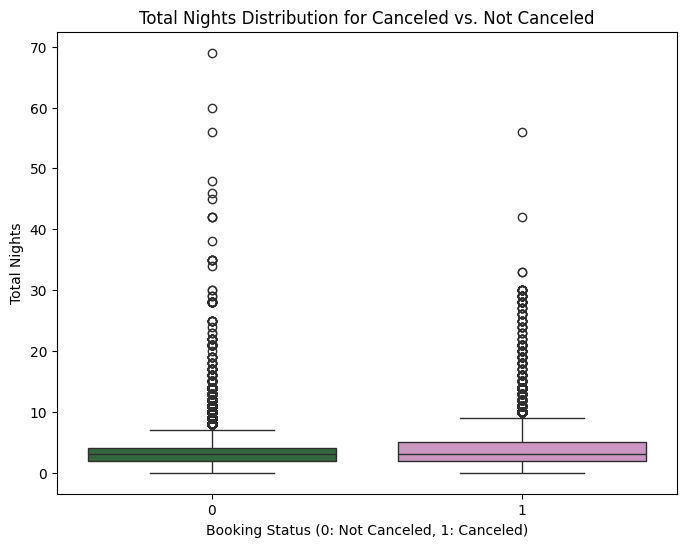

In [12]:
# Distribution of 'total_nights'
plt.figure(figsize=(10, 6))
sns.histplot(df['total_nights'], bins=20, kde=True)
plt.title('Distribution of Total Nights')
plt.xlabel('Total Nights')
plt.ylabel('Number of Bookings')
plt.show()

# Box plot for 'total_nights' by 'is_canceled'
plt.figure(figsize=(8, 6))
sns.boxplot(x='is_canceled', y='total_nights', data=df, hue='is_canceled', palette='cubehelix', legend=False)
plt.title('Total Nights Distribution for Canceled vs. Not Canceled')
plt.xlabel('Booking Status (0: Not Canceled, 1: Canceled)')
plt.ylabel('Total Nights')
plt.show()

##Export Final Dataset

In [13]:

df.to_csv('eda_final_dataset.csv', index=False)
print('✅ Final dataset exported to eda_final_dataset.csv')

✅ Final dataset exported to eda_final_dataset.csv
